# NOAA OISST Dataset Exploration & Cleaning for HAB Prediction

This notebook walks through the NOAA Optimum Interpolation Sea Surface Temperature (OISST) `.nc` files step by step:

1. **Setup** — install dependencies
2. **Download** — grab sample `.nc` files
3. **Explore** — inspect variables, dimensions, and metadata
4. **Visualize** — plot SST on a map and at California locations
5. **Extract** — pull data at CalHABMAP pier/station coordinates
6. **Clean** — handle missing values, filter by quality
7. **Feature Engineering** — rolling averages, rate of change, cumulative degree-days
8. **Export** — save a clean CSV ready for ML training

## 1. Setup

In [1]:
!pip install netCDF4 xarray requests matplotlib numpy pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [3]:
import os
import glob
import requests
from datetime import date, timedelta

import numpy as np
import pandas as pd
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 2. Download Data (2017 – Present)

Each `.nc` file = **one day** of global SST data (~1.7 MB).  
We download from **2017-01-01 to present** (~3,000+ files, ~5 GB total).  
Already-downloaded files are skipped, so you can re-run safely to catch new days.

In [4]:
BASE_URL = "https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr"
DATA_DIR = "oisst_subset"
os.makedirs(DATA_DIR, exist_ok=True)

start = date(2017, 1, 1)
end   = min(date.today(), date(2026, 4, 13))

downloaded, skipped, missing = 0, 0, 0
d = start
while d <= end:
    yyyymm   = d.strftime("%Y%m")
    yyyymmdd = d.strftime("%Y%m%d")
    fname    = f"oisst-avhrr-v02r01.{yyyymmdd}.nc"
    out_path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(out_path):
        url = f"{BASE_URL}/{yyyymm}/{fname}"
        r = requests.get(url, timeout=60)
        if r.status_code == 200:
            with open(out_path, "wb") as f:
                f.write(r.content)
            downloaded += 1
        else:
            missing += 1
    else:
        skipped += 1

    d += timedelta(days=1)

    total_expected = (end - start).days + 1
    done = downloaded + skipped + missing
    if done % 100 == 0:
        print(f"  Progress: {done}/{total_expected} days  (new={downloaded}, cached={skipped}, missing={missing})")

nc_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
print(f"\nDone! new={downloaded}, already_had={skipped}, missing={missing}")
print(f"Total .nc files available: {len(nc_files)}")
print(f"Date range: {start} to {end}")

ReadTimeout: HTTPSConnectionPool(host='www.ncei.noaa.gov', port=443): Read timed out. (read timeout=60)

## 3. Explore a Single `.nc` File

Let's crack open one file and see exactly what's inside.

### 3a. Dimensions & Global Metadata

In [ ]:
sample_file = nc_files[0]
ds = nc.Dataset(sample_file)

print("FILE:", os.path.basename(sample_file))
print("="*60)

print("\nDIMENSIONS")
print("-"*40)
for name, dim in ds.dimensions.items():
    print(f"  {name:6s}  size={len(dim):>5}  unlimited={dim.isunlimited()}")

print("\nGLOBAL ATTRIBUTES (selected)")
print("-"*40)
for key in ["title", "summary", "source", "geospatial_lat_resolution",
            "geospatial_lon_resolution", "time_coverage_start"]:
    if key in ds.ncattrs():
        print(f"  {key}: {getattr(ds, key)}")

### 3b. Variables — What Data Does Each File Contain?

| Variable | What it is | Units | Shape per file |
|----------|-----------|-------|----------------|
| **`sst`** | Daily sea surface temperature | °C | (1, 1, 720, 1440) |
| **`anom`** | SST anomaly vs 1971-2000 average | °C | (1, 1, 720, 1440) |
| **`err`** | Estimated error / uncertainty | °C | (1, 1, 720, 1440) |
| **`ice`** | Sea ice concentration | % | (1, 1, 720, 1440) |
| `lat` | Latitude grid | degrees N | (720,) |
| `lon` | Longitude grid | degrees E | (1440,) |
| `time` | Days since 1978-01-01 | days | (1,) |
| `zlev` | Depth — always 0 (surface) | meters | (1,) |

In [ ]:
print("VARIABLE DETAILS")
print("="*60)
for name, var in ds.variables.items():
    print(f"\n{name}")
    print(f"  dims:  {var.dimensions}")
    print(f"  shape: {var.shape}")
    print(f"  dtype: {var.dtype}")
    for attr in var.ncattrs():
        if attr not in ("_FillValue",):
            print(f"  {attr}: {getattr(var, attr)}")

### 3c. Quick Stats for Each Variable

In [ ]:
print(f"{'Variable':<8} {'Valid pts':>10} {'Total':>10} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
print("-"*68)

for vname in ["sst", "anom", "err", "ice"]:
    data = ds.variables[vname][:]
    valid = data.compressed() if hasattr(data, "compressed") else data.flatten()
    total = data.size
    if len(valid) > 0:
        print(f"{vname:<8} {len(valid):>10,} {total:>10,} {valid.min():>8.2f} {valid.max():>8.2f} {valid.mean():>8.2f} {valid.std():>8.2f}")
    else:
        print(f"{vname:<8} {0:>10,} {total:>10,} {'N/A':>8} {'N/A':>8} {'N/A':>8} {'N/A':>8}")

ds.close()

## 4. Visualize — Global SST Map & California Zoom

### 4a. Global SST Heatmap

In [ ]:
ds_xr = xr.open_dataset(sample_file)

sst = ds_xr["sst"].isel(time=0, zlev=0)

fig, ax = plt.subplots(figsize=(14, 5))
sst.plot(ax=ax, cmap="RdYlBu_r", vmin=-2, vmax=32,
         cbar_kwargs={"label": "SST (°C)"})
ax.set_title(f"Global Sea Surface Temperature — {os.path.basename(sample_file)}")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
plt.tight_layout()
plt.show()

ds_xr.close()

### 4b. California Coastline Zoom (SST + Anomaly)

In [ ]:
ds_xr = xr.open_dataset(sample_file)

# California bounding box: lat 32-42°N, lon 235-245°E  (=115-125°W)
ca = ds_xr.sel(lat=slice(32, 42), lon=slice(235, 245))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ca["sst"].isel(time=0, zlev=0).plot(
    ax=axes[0], cmap="RdYlBu_r", vmin=10, vmax=22,
    cbar_kwargs={"label": "°C"})
axes[0].set_title("SST — California Coast")

ca["anom"].isel(time=0, zlev=0).plot(
    ax=axes[1], cmap="RdBu_r", vmin=-3, vmax=3,
    cbar_kwargs={"label": "°C"})
axes[1].set_title("SST Anomaly — California Coast")

for ax in axes:
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

plt.tight_layout()
plt.show()
ds_xr.close()

## 5. Extract Data at CalHABMAP Station Locations

CalHABMAP monitors phytoplankton at piers along the California coast.  
We extract the **nearest OISST grid point** for each station across all downloaded days.

> **Key stations** (from [calhabmap.org/datasites](https://calhabmap.org/datasites))  
> OISST uses 0–360° longitude, so we convert: `lon_E = 360 - lon_W`

In [12]:
# CalHABMAP marine site coordinates from the screenshot list (lat °N, lon °W).
# These are approximate site positions so OISST can be sampled at the nearest grid cell.
STATIONS = {
    "Bodega Marine Lab Buoy":        (38.316, 123.074),
    "Bodega Marine Lab":             (38.319, 123.073),
    "Cal Poly Pier":                 (35.170, 120.740),
    "Humboldt South Bay":            (40.726, 124.224),
    "Humboldt":                      (40.766, 124.217),
    "Inner Tomales Bay":             (38.156, 122.873),
    "Monterey Wharf":                (36.605, 121.889),
    "Newport Beach Pier":            (33.607, 117.931),
    "Santa Cruz Wharf":              (36.959, 122.017),
    "Santa Monica Pier":             (34.008, 118.497),
    "Scripps Pier":                  (32.867, 117.257),
    "Stearns Wharf":                 (34.408, 119.685),
    "Tomales Bay Mid-Channel Buoy":  (38.169, 122.900),
    "Tomales Bay Mouth":             (38.226, 122.992),
    "Trinidad Pier":                 (41.052, 124.143),
}

# Convert lon_W to lon_E (OISST uses 0-360)
stations_E = {name: (lat, 360 - lon_w) for name, (lat, lon_w) in STATIONS.items()}

print(f"{'Station':<30} {'Lat °N':>8} {'Lon °W':>8} {'Lon °E':>8}")
print("-"*62)
for name, (lat, lon_e) in stations_E.items():
    print(f"{name:<30} {lat:>8.3f} {360-lon_e:>8.3f} {lon_e:>8.3f}")

Station                          Lat °N   Lon °W   Lon °E
--------------------------------------------------------------
Bodega Marine Lab Buoy           38.316  123.074  236.926
Bodega Marine Lab                38.319  123.073  236.927
Cal Poly Pier                    35.170  120.740  239.260
Humboldt South Bay               40.726  124.224  235.776
Humboldt                         40.766  124.217  235.783
Inner Tomales Bay                38.156  122.873  237.127
Monterey Wharf                   36.605  121.889  238.111
Newport Beach Pier               33.607  117.931  242.069
Santa Cruz Wharf                 36.959  122.017  237.983
Santa Monica Pier                34.008  118.497  241.503
Scripps Pier                     32.867  117.257  242.743
Stearns Wharf                    34.408  119.685  240.315
Tomales Bay Mid-Channel Buoy     38.169  122.900  237.100
Tomales Bay Mouth                38.226  122.992  237.008
Trinidad Pier                    41.052  124.143  235.857


In [1]:
def extract_station_data(nc_files, stations_E, max_search_radius=4):
    """Extract sst, anom, err at each station for every .nc file.

    If the nearest OISST grid cell is masked, search a small neighborhood
    for the nearest unmasked ocean cell instead of coercing masked values to NaN.
    """
    def nearest_valid_index(mask, lat_i, lon_i, max_radius):
        if not mask[lat_i, lon_i]:
            return lat_i, lon_i

        best = None
        best_dist2 = None

        for radius in range(1, max_radius + 1):
            i0 = max(0, lat_i - radius)
            i1 = min(mask.shape[0], lat_i + radius + 1)
            j0 = max(0, lon_i - radius)
            j1 = min(mask.shape[1], lon_i + radius + 1)

            for ii in range(i0, i1):
                for jj in range(j0, j1):
                    if mask[ii, jj]:
                        continue

                    dist2 = (ii - lat_i) ** 2 + (jj - lon_i) ** 2
                    if best is None or dist2 < best_dist2:
                        best = (ii, jj)
                        best_dist2 = dist2

            if best is not None:
                return best

        return None

    rows = []

    for fpath in nc_files:
        ds = nc.Dataset(fpath)
        lat_arr = ds.variables["lat"][:]
        lon_arr = ds.variables["lon"][:]
        sst_grid = ds.variables["sst"][0, 0, :, :]
        anom_grid = ds.variables["anom"][0, 0, :, :]
        err_grid = ds.variables["err"][0, 0, :, :]
        ocean_mask = np.ma.getmaskarray(sst_grid)

        # Parse date from filename
        fname = os.path.basename(fpath)
        date_str = fname.split(".")[1]  # e.g. "20200601"
        file_date = pd.to_datetime(date_str, format="%Y%m%d")

        for station_name, (st_lat, st_lon) in stations_E.items():
            lat_i = int(np.argmin(np.abs(lat_arr - st_lat)))
            lon_i = int(np.argmin(np.abs(lon_arr - st_lon)))
            valid_idx = nearest_valid_index(ocean_mask, lat_i, lon_i, max_search_radius)

            if valid_idx is None:
                sample_lat = lat_arr[lat_i]
                sample_lon = lon_arr[lon_i]
                sst_val = np.nan
                anom_val = np.nan
                err_val = np.nan
            else:
                sample_lat_i, sample_lon_i = valid_idx
                sample_lat = lat_arr[sample_lat_i]
                sample_lon = lon_arr[sample_lon_i]
                sst_val = float(np.ma.filled(sst_grid[sample_lat_i, sample_lon_i], np.nan))
                anom_val = float(np.ma.filled(anom_grid[sample_lat_i, sample_lon_i], np.nan))
                err_val = float(np.ma.filled(err_grid[sample_lat_i, sample_lon_i], np.nan))

            rows.append({
                "date":    file_date,
                "station": station_name,
                "lat":     sample_lat,
                "lon":     sample_lon,
                "sst":     sst_val,
                "anom":    anom_val,
                "err":     err_val,
            })

        ds.close()

    return pd.DataFrame(rows)

df_raw = extract_station_data(nc_files, stations_E)
print(f"Extracted {len(df_raw)} rows  ({df_raw['station'].nunique()} stations × {df_raw['date'].nunique()} days)")
df_raw.head(10)

NameError: name 'nc_files' is not defined

### 5a. Quick Look — SST Time Series per Station

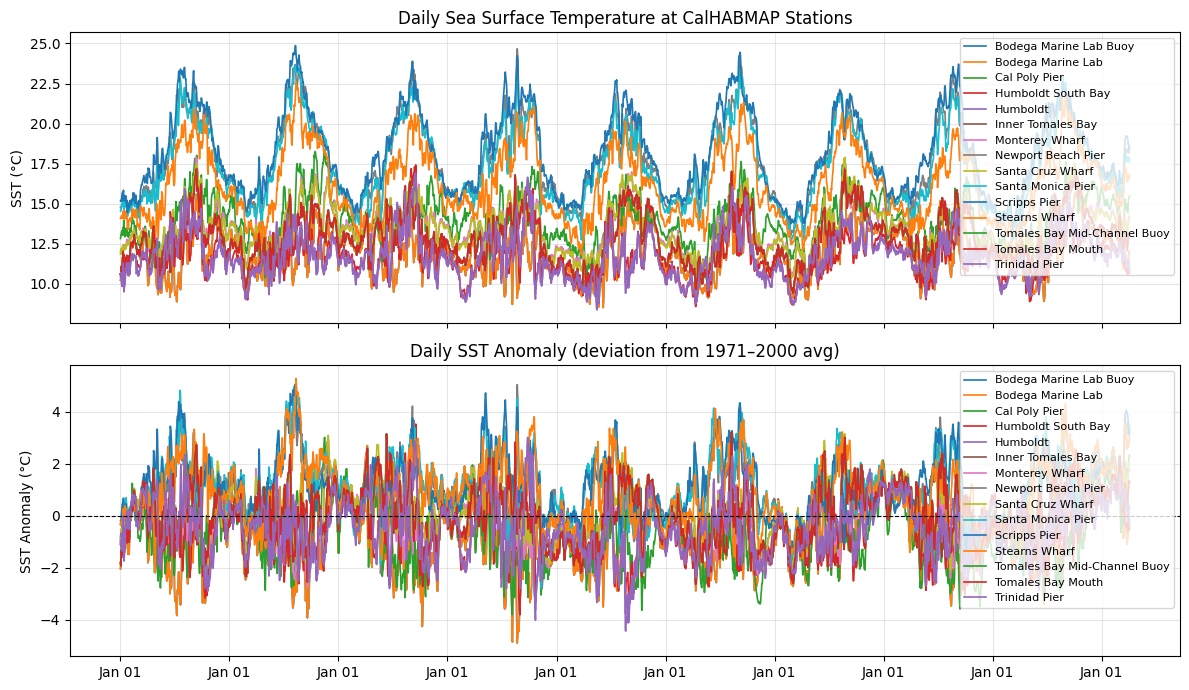

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for station in df_raw["station"].unique():
    sub = df_raw[df_raw["station"] == station].sort_values("date")
    axes[0].plot(sub["date"], sub["sst"],  label=station, linewidth=1.2)
    axes[1].plot(sub["date"], sub["anom"], label=station, linewidth=1.2)

axes[0].set_ylabel("SST (°C)")
axes[0].set_title("Daily Sea Surface Temperature at CalHABMAP Stations")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("SST Anomaly (°C)")
axes[1].set_title("Daily SST Anomaly (deviation from 1971–2000 avg)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

## 6. Data Cleaning

Steps:
1. **Drop masked/missing values** — OISST uses a fill value of -999, which netCDF4 auto-masks to `NaN`
2. **Filter by error threshold** — remove readings with high uncertainty
3. **Sanity-check SST range** — valid ocean temps are roughly -2 to 35 °C
4. **Check for duplicate dates per station**
5. **Fill small gaps** via interpolation (if any remain)

In [23]:
df = df_raw.copy()
print(f"Starting rows: {len(df)}")

# Step 1: Drop rows where SST is NaN (masked/missing in the .nc file)
before = len(df)
df = df.dropna(subset=["sst", "anom"])
print(f"After dropping NaN sst/anom: {len(df)}  (removed {before - len(df)})")

# Step 2: Filter by error — keep only readings with err < 0.5°C
ERR_THRESHOLD = 0.5
before = len(df)
df = df[df["err"] < ERR_THRESHOLD]
print(f"After error filter (<{ERR_THRESHOLD}°C): {len(df)}  (removed {before - len(df)})")

# Step 3: Sanity-check SST range
before = len(df)
df = df[(df["sst"] >= -2) & (df["sst"] <= 35)]
print(f"After SST range filter (-2 to 35°C): {len(df)}  (removed {before - len(df)})")

# Step 4: Check for duplicates
dupes = df.duplicated(subset=["date", "station"], keep="first")
print(f"Duplicate (date, station) rows: {dupes.sum()}")
df = df[~dupes]

print(f"\nClean rows: {len(df)}")
df.head()

Starting rows: 50715
After dropping NaN sst/anom: 50715  (removed 0)
After error filter (<0.5°C): 50715  (removed 0)
After SST range filter (-2 to 35°C): 50715  (removed 0)
Duplicate (date, station) rows: 0

Clean rows: 50715


,date,station,lat,lon,sst,anom,err
0,2017-01-01,Bodega Marine Lab Buoy,38.375,236.875,10.219999,-2.04,0.18
1,2017-01-01,Bodega Marine Lab,38.375,236.875,10.219999,-2.04,0.18
2,2017-01-01,Cal Poly Pier,35.125,239.375,12.820000,-0.99,0.20
3,2017-01-01,Humboldt South Bay,40.625,235.625,10.620000,-1.02,0.21
4,2017-01-01,Humboldt,40.875,235.875,10.410000,-1.10,0.26


### 6a. Check for Missing Days & Interpolate Small Gaps

In [24]:
# Pivot to see the full date × station grid, then check for gaps
date_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
stations = df["station"].unique()

print("Missing days per station:")
for st in stations:
    st_dates = set(df[df["station"] == st]["date"])
    missing = [d for d in date_range if d not in st_dates]
    print(f"  {st}: {len(missing)} missing out of {len(date_range)} days")

# Reindex to fill small gaps (up to 3 consecutive days) with linear interpolation
filled_parts = []
for st in stations:
    sub = df[df["station"] == st].set_index("date").sort_index()
    sub = sub.reindex(date_range)
    sub["station"] = st
    # Forward-fill station metadata, interpolate numeric columns
    sub[["lat", "lon"]] = sub[["lat", "lon"]].ffill()
    sub[["sst", "anom", "err"]] = sub[["sst", "anom", "err"]].interpolate(
        method="linear", limit=3  # only fill gaps up to 3 days
    )
    filled_parts.append(sub)

df_clean = pd.concat(filled_parts).reset_index().rename(columns={"index": "date"})
df_clean = df_clean.dropna(subset=["sst"])  # drop any remaining gaps > 3 days

print(f"\nAfter gap-filling: {len(df_clean)} rows")
df_clean.head()

Missing days per station:
  Bodega Marine Lab Buoy: 0 missing out of 3381 days
  Bodega Marine Lab: 0 missing out of 3381 days
  Cal Poly Pier: 0 missing out of 3381 days
  Humboldt South Bay: 0 missing out of 3381 days
  Humboldt: 0 missing out of 3381 days
  Inner Tomales Bay: 0 missing out of 3381 days
  Monterey Wharf: 0 missing out of 3381 days
  Newport Beach Pier: 0 missing out of 3381 days
  Santa Cruz Wharf: 0 missing out of 3381 days
  Santa Monica Pier: 0 missing out of 3381 days
  Scripps Pier: 0 missing out of 3381 days
  Stearns Wharf: 0 missing out of 3381 days
  Tomales Bay Mid-Channel Buoy: 0 missing out of 3381 days
  Tomales Bay Mouth: 0 missing out of 3381 days
  Trinidad Pier: 0 missing out of 3381 days

After gap-filling: 50715 rows


,date,station,lat,lon,sst,anom,err
0,2017-01-01,Bodega Marine Lab Buoy,38.375,236.875,10.219999,-2.04,0.18
1,2017-01-02,Bodega Marine Lab Buoy,38.375,236.875,10.300000,-1.94,0.21
2,2017-01-03,Bodega Marine Lab Buoy,38.375,236.875,10.510000,-1.72,0.26
3,2017-01-04,Bodega Marine Lab Buoy,38.375,236.875,10.700000,-1.52,0.23
4,2017-01-05,Bodega Marine Lab Buoy,38.375,236.875,10.599999,-1.60,0.18


## 7. Feature Engineering

These features capture the **temporal patterns** that trigger harmful algal blooms:

| Feature | Why it matters for HABs |
|---------|------------------------|
| Rolling mean SST (7/14/30d) | Sustained warm water promotes algal growth |
| Rolling mean anomaly | Prolonged above-normal temps = heatwave conditions |
| SST rate of change | Rapid warming can trigger bloom onset |
| Cumulative warm days | Total heat exposure over a window |
| Anomaly > 0 flag | Binary: is the water warmer than average? |

In [25]:
df_feat = df_clean.sort_values(["station", "date"]).copy()

# Group by station so rolling windows don't bleed across locations
grouped = df_feat.groupby("station")

# Rolling mean SST
for window in [7, 14, 30, 90]:
    df_feat[f"sst_roll_{window}d"] = grouped["sst"].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

# Rolling mean anomaly
for window in [7, 14, 30]:
    df_feat[f"anom_roll_{window}d"] = grouped["anom"].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

# SST rate of change (°C per day, using 3-day difference)
df_feat["sst_roc_3d"] = grouped["sst"].transform(
    lambda x: x.diff(3) / 3
)

# Cumulative warm degree-days in last 14 days
# (sum of positive anomalies over a 14-day window)
df_feat["warm_degree_days_14d"] = grouped["anom"].transform(
    lambda x: x.clip(lower=0).rolling(14, min_periods=1).sum()
)

# Binary flag: water warmer than historical average
df_feat["above_avg"] = (df_feat["anom"] > 0).astype(int)

print(f"Features created. Shape: {df_feat.shape}")
print(f"\nColumns: {list(df_feat.columns)}")
df_feat.head(10)

Features created. Shape: (50715, 17)

Columns: ['date', 'station', 'lat', 'lon', 'sst', 'anom', 'err', 'sst_roll_7d', 'sst_roll_14d', 'sst_roll_30d', 'sst_roll_90d', 'anom_roll_7d', 'anom_roll_14d', 'anom_roll_30d', 'sst_roc_3d', 'warm_degree_days_14d', 'above_avg']


,date,station,lat,lon,sst,anom,err,sst_roll_7d,sst_roll_14d,sst_roll_30d,sst_roll_90d,anom_roll_7d,anom_roll_14d,anom_roll_30d,sst_roc_3d,warm_degree_days_14d,above_avg
3381,2017-01-01,Bodega Marine Lab,38.375,236.875,10.219999,-2.04,0.18,10.219999,10.219999,10.219999,10.219999,-2.040000,-2.040000,-2.040000,NaN,0.0,0
3382,2017-01-02,Bodega Marine Lab,38.375,236.875,10.300000,-1.94,0.21,10.260000,10.260000,10.260000,10.260000,-1.990000,-1.990000,-1.990000,NaN,0.0,0
3383,2017-01-03,Bodega Marine Lab,38.375,236.875,10.510000,-1.72,0.26,10.343333,10.343333,10.343333,10.343333,-1.900000,-1.900000,-1.900000,NaN,0.0,0
3384,2017-01-04,Bodega Marine Lab,38.375,236.875,10.700000,-1.52,0.23,10.432500,10.432500,10.432500,10.432500,-1.805000,-1.805000,-1.805000,0.160000,0.0,0
3385,2017-01-05,Bodega Marine Lab,38.375,236.875,10.599999,-1.60,0.18,10.466000,10.466000,10.466000,10.466000,-1.764000,-1.764000,-1.764000,0.100000,0.0,0
3386,2017-01-06,Bodega Marine Lab,38.375,236.875,10.690000,-1.50,0.20,10.503333,10.503333,10.503333,10.503333,-1.720000,-1.720000,-1.720000,0.060000,0.0,0
3387,2017-01-07,Bodega Marine Lab,38.375,236.875,10.820000,-1.35,0.29,10.548571,10.548571,10.548571,10.548571,-1.667143,-1.667143,-1.667143,0.040000,0.0,0
3388,2017-01-08,Bodega Marine Lab,38.375,236.875,11.120000,-1.04,0.29,10.677143,10.620000,10.620000,10.620000,-1.524286,-1.588750,-1.588750,0.173333,0.0,0
3389,2017-01-09,Bodega Marine Lab,38.375,236.875,11.570000,-0.57,0.28,10.858571,10.725555,10.725555,10.725555,-1.328571,-1.475556,-1.475556,0.293333,0.0,0
3390,2017-01-10,Bodega Marine Lab,38.375,236.875,12.000000,-0.13,0.29,11.071428,10.853000,10.853000,10.853000,-1.101429,-1.341000,-1.341000,0.393333,0.0,0


### 7a. Visualize Engineered Features

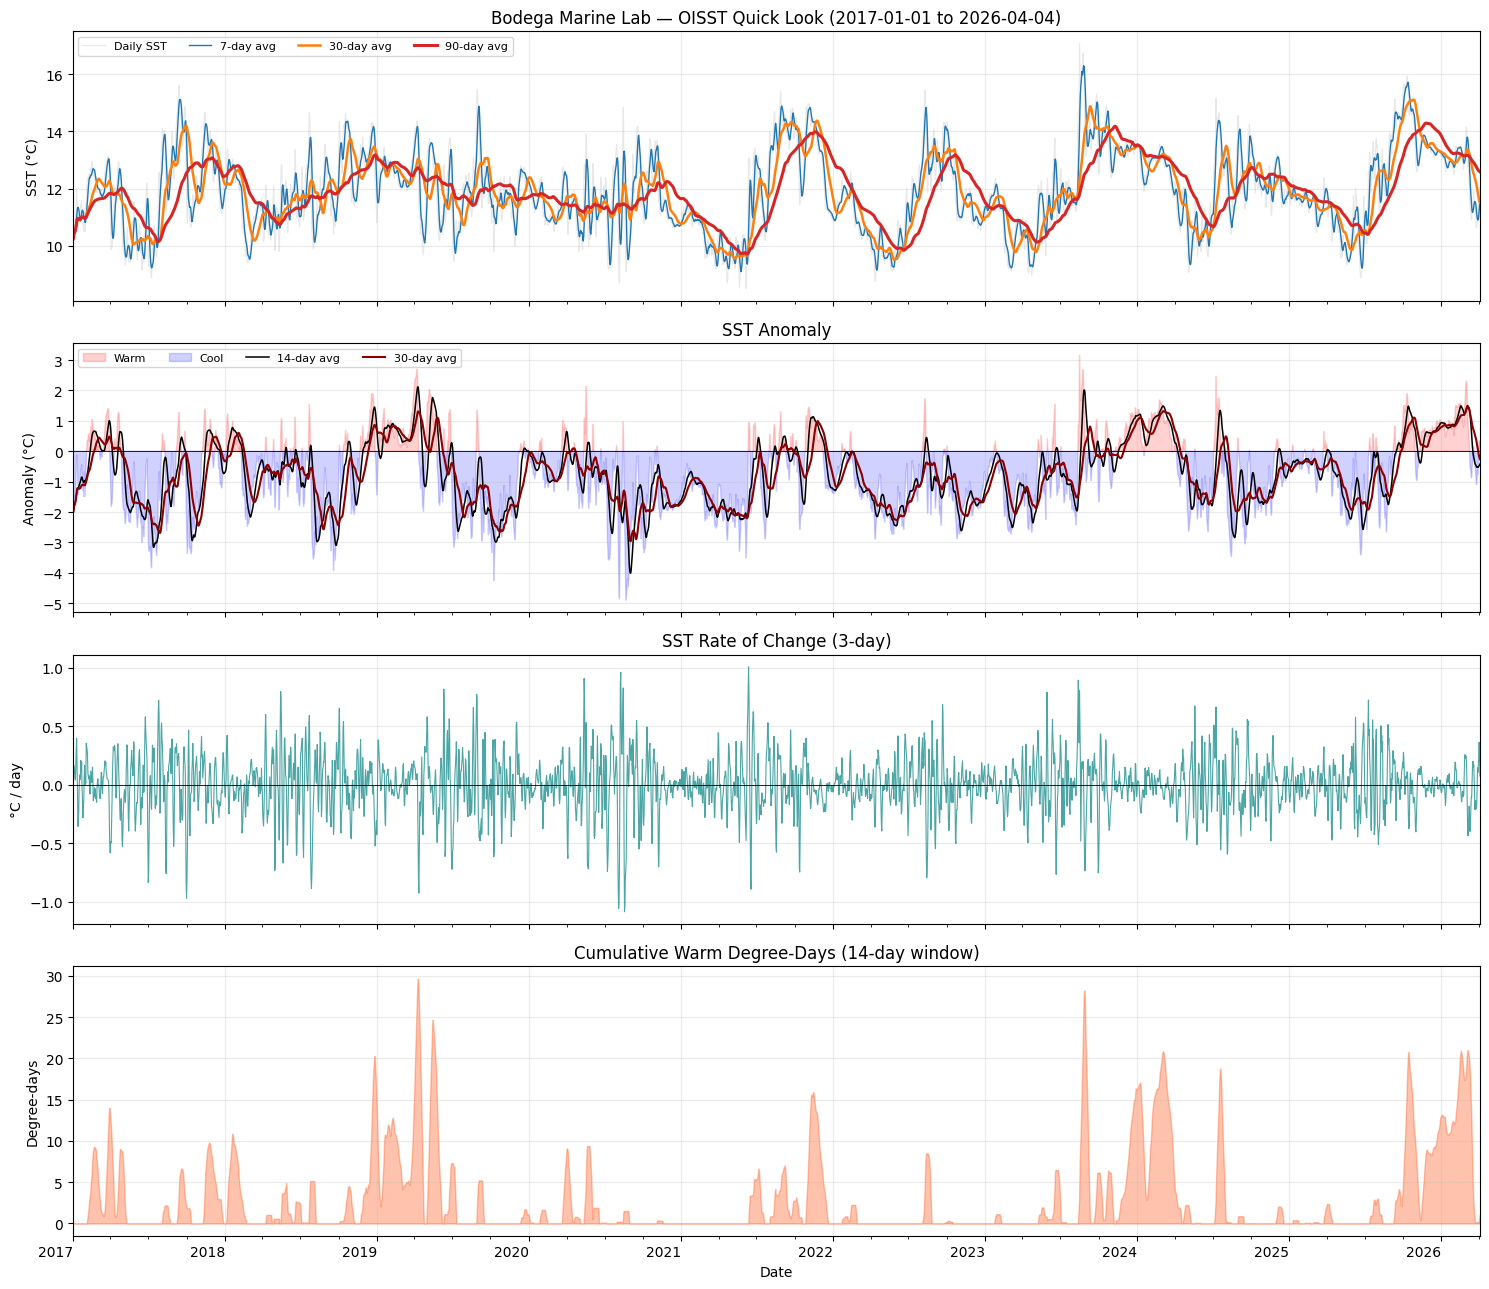

In [26]:
sample_station = sorted(df_feat["station"].unique())[0]
sub = df_feat[df_feat["station"] == sample_station].sort_values("date").copy()

date_min = sub["date"].min()
date_max = sub["date"].max()
year_locator = mdates.YearLocator()
month_locator = mdates.MonthLocator(bymonth=(1, 4, 7, 10))
year_fmt = mdates.DateFormatter("%Y")

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)

# Raw SST + rolling averages. Keep the daily line light so the smoothed signal
# remains readable across the full 2017-present record.
axes[0].plot(sub["date"], sub["sst"], color="0.75", alpha=0.35, linewidth=0.8, label="Daily SST")
axes[0].plot(sub["date"], sub["sst_roll_7d"], color="tab:blue", linewidth=1.0, label="7-day avg")
axes[0].plot(sub["date"], sub["sst_roll_30d"], color="tab:orange", linewidth=1.8, label="30-day avg")
axes[0].plot(sub["date"], sub["sst_roll_90d"], color="tab:red", linewidth=2.2, label="90-day avg")
axes[0].set_ylabel("SST (°C)")
axes[0].set_title(
    f"{sample_station} — OISST Quick Look ({date_min:%Y-%m-%d} to {date_max:%Y-%m-%d})"
)
axes[0].legend(fontsize=8, ncol=4, loc="upper left")
axes[0].grid(True, alpha=0.25)

# Anomaly
axes[1].fill_between(
    sub["date"], 0, sub["anom"], where=sub["anom"] > 0,
    color="red", alpha=0.18, interpolate=True, label="Warm"
)
axes[1].fill_between(
    sub["date"], 0, sub["anom"], where=sub["anom"] <= 0,
    color="blue", alpha=0.18, interpolate=True, label="Cool"
)
axes[1].plot(sub["date"], sub["anom_roll_14d"], color="black", linewidth=1.1, label="14-day avg")
axes[1].plot(sub["date"], sub["anom_roll_30d"], color="darkred", linewidth=1.5, label="30-day avg")
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set_ylabel("Anomaly (°C)")
axes[1].set_title("SST Anomaly")
axes[1].legend(fontsize=8, ncol=4, loc="upper left")
axes[1].grid(True, alpha=0.25)

# Rate of change. Use a thin line instead of dense bars for long time spans.
axes[2].plot(sub["date"], sub["sst_roc_3d"], color="teal", alpha=0.7, linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.6)
axes[2].set_ylabel("°C / day")
axes[2].set_title("SST Rate of Change (3-day)")
axes[2].grid(True, alpha=0.25)

# Cumulative warm degree-days
axes[3].fill_between(
    sub["date"], 0, sub["warm_degree_days_14d"], color="orangered", alpha=0.32
)
axes[3].set_ylabel("Degree-days")
axes[3].set_title("Cumulative Warm Degree-Days (14-day window)")
axes[3].grid(True, alpha=0.25)

for ax in axes:
    ax.set_xlim(date_min, date_max)
    ax.xaxis.set_major_locator(year_locator)
    ax.xaxis.set_major_formatter(year_fmt)
    ax.xaxis.set_minor_locator(month_locator)

axes[3].set_xlabel("Date")
fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.show()

## 8. Export Clean Dataset

Save to CSV — ready to merge with CalHABMAP labels and NDBC buoy features for ML training.

In [27]:
OUT_CSV = "oisst_california_all_sites_clean.csv"

# Drop rows with NaN in any engineered feature
df_export = df_feat.dropna()

# Final column order
col_order = [
    "date", "station", "lat", "lon",
    "sst", "anom", "err",
    "sst_roll_7d", "sst_roll_14d", "sst_roll_30d", "sst_roll_90d",
    "anom_roll_7d", "anom_roll_14d", "anom_roll_30d",
    "sst_roc_3d", "warm_degree_days_14d", "above_avg",
]
df_export = df_export[col_order].sort_values(["station", "date"])

df_export.to_csv(OUT_CSV, index=False)
print(f"Saved {len(df_export)} rows to {OUT_CSV}")
print(f"Columns: {list(df_export.columns)}")
print(f"Date range: {df_export['date'].min()} to {df_export['date'].max()}")
print(f"Stations: {df_export['station'].nunique()}")
print(f"\nSample:")
df_export.head()

Saved 50670 rows to oisst_california_all_sites_clean.csv
Columns: ['date', 'station', 'lat', 'lon', 'sst', 'anom', 'err', 'sst_roll_7d', 'sst_roll_14d', 'sst_roll_30d', 'sst_roll_90d', 'anom_roll_7d', 'anom_roll_14d', 'anom_roll_30d', 'sst_roc_3d', 'warm_degree_days_14d', 'above_avg']
Date range: 2017-01-04 00:00:00 to 2026-04-04 00:00:00
Stations: 15

Sample:


,date,station,lat,lon,sst,anom,err,sst_roll_7d,sst_roll_14d,sst_roll_30d,sst_roll_90d,anom_roll_7d,anom_roll_14d,anom_roll_30d,sst_roc_3d,warm_degree_days_14d,above_avg
3384,2017-01-04,Bodega Marine Lab,38.375,236.875,10.700000,-1.52,0.23,10.432500,10.432500,10.432500,10.432500,-1.805000,-1.805000,-1.805000,0.160000,0.0,0
3385,2017-01-05,Bodega Marine Lab,38.375,236.875,10.599999,-1.60,0.18,10.466000,10.466000,10.466000,10.466000,-1.764000,-1.764000,-1.764000,0.100000,0.0,0
3386,2017-01-06,Bodega Marine Lab,38.375,236.875,10.690000,-1.50,0.20,10.503333,10.503333,10.503333,10.503333,-1.720000,-1.720000,-1.720000,0.060000,0.0,0
3387,2017-01-07,Bodega Marine Lab,38.375,236.875,10.820000,-1.35,0.29,10.548571,10.548571,10.548571,10.548571,-1.667143,-1.667143,-1.667143,0.040000,0.0,0
3388,2017-01-08,Bodega Marine Lab,38.375,236.875,11.120000,-1.04,0.29,10.677143,10.620000,10.620000,10.620000,-1.524286,-1.588750,-1.588750,0.173333,0.0,0


## Summary

### What each `.nc` file contains
| Variable | Role in HAB pipeline | Use as |
|----------|---------------------|--------|
| `sst` | Water temperature — primary bloom driver | ML feature |
| `anom` | Deviation from normal — flags heatwaves | ML feature |
| `err` | Data quality indicator | Filter (drop if > 0.5°C) |
| `ice` | Sea ice — zero for California | Ignore |

### Engineered features for ML
| Feature | Description |
|---------|-------------|
| `sst_roll_7/14/30d` | Smoothed SST trends |
| `anom_roll_7/14/30d` | Smoothed anomaly trends |
| `sst_roc_3d` | How fast temp is changing |
| `warm_degree_days_14d` | Cumulative heat exposure |
| `above_avg` | Binary warm flag |

### Next steps
1. **Merge with CalHABMAP** labels by `date` and `station` → creates the supervised training set
2. **Add NDBC buoy data** (wind, pressure) as additional features
3. **Train/test split** by time (e.g. train on 2015–2019, test on 2020)
4. **Train baseline** → logistic regression, then random forest / XGBoost